In [6]:
import matplotlib.pyplot as plt
import numpy as np

### Skewing the temperature

It took me a long time to figure out that we need to use the temperature skew function as a final step before plotting. I started working with the isotherms as a background check to know I was implementing the function properly. Once I got that, I applied on my plot block after obtaining each "family" of lines thet were T-dependent

In [9]:
def skewT(temp, pres, skew=-20):
    """Skews the temperature axis for a SkewT plot.
temp: temperature values (deg C)
pres: pressure values (hPa)
skew: amount of skew (default of -20)"""

    return (temp) + skew * np.log(pres/1000.0)

### Constants definition
Just as a reminder, super important to clarify the units. I always try to work using IS and, if not, I make explicit what alternative I use. Before approaching the lab, I wanted to pay special attention to not confusing Celsius with Kelvin and to account for the use of hPa instead of Pa when necessary.

In [15]:
# Definition of the necessary constants:
R_d = 287 # J / kg·K
R_v = 461 # J / kg·K
c_pd = 1004 # J / kg·K
L_v = 2.5e6 # J / kg
eps = 0.622 # = R_d/R_v, Adimensional
g = 9.81 # m / s^2

### Dry adiabats
For the plotting of the dry adiabats I decided to use the potental temperature equation. The potential temperature is defined as the reference temperature when an air parcel is interacting with its environment through adiabatic processes (so, without exchanging heat). So, considering an inital temperature $T_0$ and an initial pressure $p_0=1000~hPa$, we can, using the expression $$\theta=T\left(\frac{p_0}{p}\right)^{R/c_p}$$ derive the corresponding adiabatic trajectories as we increase the pressure.

### Moist adiabats
#### Calculating the changes in T with p at every level

For the representation of the moist adiabats, and considering the following expressions: 
$$e_s(T)=6.112\cdot \exp{17.67\frac{T-273.15}{T-29.65}}$$
$$r_s(T, p)=\epsilon\cdot\frac{e_s(T)}{p-e_s(T)}$$
$$\epsilon=\frac{R_d}{R_v}\approx 0.622$$
$$\Gamma_m\equiv -\frac{dT}{dz}=\frac{g}{c_{pd}}\frac{1+\frac{L_vr_s}{R_dT}}{1+\frac{L_v^2r_s}{c_pdR_vT^2}}$$

And then changing the vertical coordinate from $z$ to $p$ via the implementation of the hydrostatic balance:
$$\frac{dT}{dp}=-\frac{1}{\rho g}\frac{dT}{dz}=\frac{g\alpha}{c_{pd}\rho g}=\frac{\alpha}{c_{pd}\rho}, ~~\alpha = \frac{1+\frac{L_vr_s}{R_dT}}{1+\frac{L_v^2r_s}{c_pdR_vT^2}}$$

We obtain an expression for the change in temperature with pressure followed in a moist adiabatic regime. This expression depends on the temperature $T$ and the pressure $p$ on each considered vertical level, so we can re-calculate the temperature evolution at every pressure-step considered:

$$\frac{dT}{dp}\approx\frac{\Delta T}{\Delta p}=\frac{T_f-T_i}{p_f-p_i}$$
$$T_f\approx T_i+ \frac{dT}{dp} \cdot (p_f-p_i)=T_i+ \frac{\alpha}{c_{pd}\rho} \cdot (p_f-p_i)$$
, And mind that $p_f-p_i<0$ because pressure decreases as we ascend from the surface.

In [24]:
# Definition of the initial functions:
    # Dry adiabats
def pot_T(T0, p, p0=1000):
    """Evolution of temperature following a dry adiabatic process. Returns 
    the final temperature in Celsius, ready to be skewwed and then plotted.
        T0: Initial temperature, Celsius
        p: environmental pressure, hPa
        p0: reference pressure, hPa"""
    T0_K = T0 + 273.15
    T_K = T0_K * (p / p0)**(R_d/c_pd)
    return T_K - 273.15

    # Moist Adiabats
def e_s(T):
    """This function returns hPa. Temperatures must be in K in return
        e_s(T): saturation vapour pressure, hPa
        T: temp. where I calculate the pressure, Celsius"""
    T_K = T + 273.15
    return (6.112 * np.exp(17.67 * ((T_K-273.15)/(T_K-29.65))))

def r_s(e_s, p):
    """Expression for the mixing ratio. Both pressures are in hPa.
    epsilon is adimensional and the return value is also adimensional.
        e_s: saturation vapour pressure, hPa
        p: environment pressure, hPa"""
    return (eps * ((e_s)/(p-e_s)))

def rho(T, p):
    """Calculates air density following the ideal gas law. Returns density in IS units.
        T: environment temperature, Celsius
        p: environment pressure, hPa"""
    return (p*100) / (R_d * (T+273.15))

def alpha(r_s, T):
    """alpha is adimensional, all of the parameters in the "return" must be 
    expressed using the IS.
        r_s: mixing ratio at the considered level, adimensional
        T: initial temperature at a given level, Celsius"""
    T_K = T + 273.15
    return ((1+(L_v * r_s)/(R_d * T_K))/(1 + (L_v**2 * r_s)/(c_pd * R_v * T_K**2)))

def dT_dp(alpha, rho):
    """The units of the differential are K(or C)/Pa (IS)
        alpha: adimensional
        rho: air density at a given vertical level, kg/m^3"""
    return (alpha / (c_pd * rho))

In [26]:
# Definition of the different arrays used for plotting:
pres_guides = [1000, 900, 800, 700, 600, 500, 400, 300, 200, 100] #Pressure lines for plot reference, hPa
pres = np.arange(1000, 99, -1) #Leaps of pressure for profiles every 1 hPa (100 Pa!!!)

temp_IT = np.arange(-80, 51, 10) #Isotherms, Celsius
temp_DA = np.arange(-40, 251, 10) #Dry Adiabats, Celsius
temp_MA = np.arange(-40, 251, 5) #Moist Adiabats, increase frequency for better visibility, Celsius

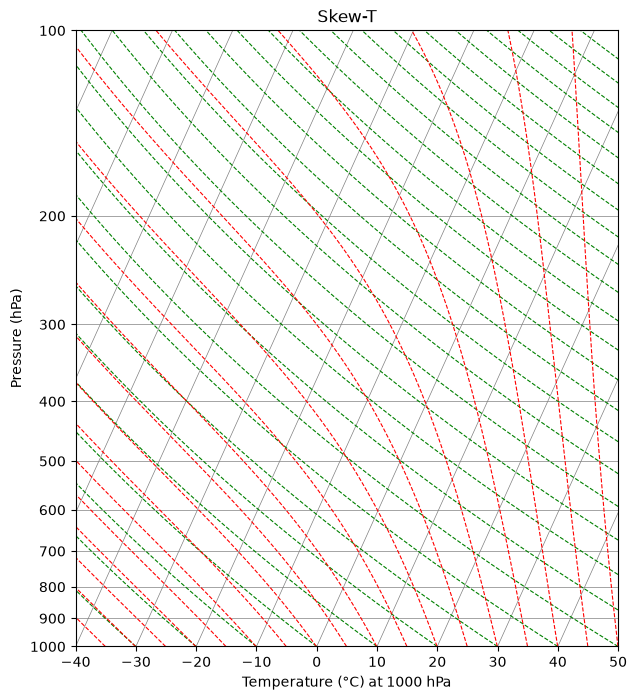

In [ ]:
# Figure definition
fig, ax = plt.subplots(figsize=(7, 8))
ax.set_yscale("log") #Pressure in log (base 10) scale
ax.set_ylim(1000, 100) # In hPa
ax.set_xlim(-40, 50) # In Celsius

# Isotherms
for T0 in temp_IT:

    T_sk = skewT(T0, pres, skew=-20)

    ax.plot(
        T_sk, pres,
        color="grey",
        linewidth=0.5
    )

# Isobars
for p in pres_guides:
    ax.axhline(
        p,
        color="grey",
        linewidth=0.5
    )

# Dry adiabats
for T0 in temp_DA:

    # Temperature along the dry adiabat
    T = pot_T(T0, pres)

    # Transform into Skew-T coordinates
    T_sk = skewT(T, pres, skew=-20)

    ax.plot(
        T_sk, pres,
        color="green",
        linestyle="--",
        linewidth=0.8
    )

# Moist adiabats
for T0 in temp_MA:
    T_MA=[] # Array that will be filled with the moist-adiabat evolution of a parcel starting at T0, p0
    for p0 in pres:
        #alculating the variables for each (T,p) level
        e_s0=e_s(T0)
        r_s0=r_s(e_s0, p0)
        rho0=rho(T0, p0)
        alpha0=alpha(r_s0, T0)
        dT_dp0=dT_dp(alpha0, rho0)

        Tf = T0 + dT_dp0 * (-100) # increment of 1 hPa is 100 Pa. Negative because p decreases w height!!!
        T_MA = np.append(T_MA, Tf) # for every level, we append the corresponding evolution of T
        T0 = Tf # We initialize the temperature for the next iteration
    
    # Transform into Skew-T
    T_sk = skewT(T_MA, pres, skew=-20)
    ax.plot(
            T_sk, pres,
            linestyle="--",
            color="red",
            linewidth=0.8)


    # Axis configuration
ax.set_yticks(pres_guides)
ax.set_yticklabels([str(p) for p in pres_guides]) # Use the same array as the isobars
ax.minorticks_off()

ax.set_xlabel("Temperature (°C) at 1000 hPa")
ax.set_ylabel("Pressure (hPa)")
ax.set_title("Skew-T")

plt.show()

## Proofs of concept
In this section I want to check that the behaviour of the adiabats is consistent with theory.
### Dry adiabats
For the dry adiabats, the following ratios should be preserved during an adiabatic trajectory:
$$\theta(p)^{R/c_p}=T(p_0)^{R/c_p}$$
, where $T$ is the given temperature in K at the level $p_0=1000~hPa$. We can check that this relation holds for a given initial level:

In [ ]:
ratio = (20 + 273.15)*(1000)**(R_d)